In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
import tensorflow as tf

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
datagen = ImageDataGenerator(rescale=1./255)


In [14]:
train_generator = datagen.flow_from_directory("dataset/train//", target_size=(64, 64), class_mode="categorical")

Found 18900 images belonging to 10 classes.


In [15]:
test_generator = datagen.flow_from_directory("dataset/test/", target_size=(64, 64), class_mode="categorical")

Found 8100 images belonging to 10 classes.


In [20]:
train_generator

In [21]:
data, label = next(train_generator)
data.shape

(32, 64, 64, 3)

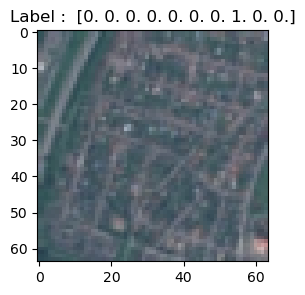

In [26]:
plt.figure(figsize=(3, 3))
plt.imshow(data[31])
plt.title(f"Label :  {label[31]}")
plt.show()

In [28]:
cnn = tf.keras.models.Sequential()

cnn.add(tf.keras.layers.Conv2D(32, 3, activation="relu", input_shape=(64, 64, 3)))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Conv2D(32, 3, activation="relu"))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

cnn.add(tf.keras.layers.Flatten())

cnn.add(tf.keras.layers.Dense(128, activation="relu"))

cnn.add(tf.keras.layers.Dense(10, activation="softmax"))

In [29]:
cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [30]:
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 29, 29, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         802,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 814,378 (3.11 MB)

 Trainable params: 814,378 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
result = cnn.fit(x=train_generator, epochs=20)

Epoch 1/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - accuracy: 0.6825 - loss: 0.8702
Epoch 2/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 39s 66ms/step - accuracy: 0.7446 - loss: 0.7111
Epoch 3/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 38s 65ms/step - accuracy: 0.7722 - loss: 0.6357
Epoch 4/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 39s 65ms/step - accuracy: 0.7977 - loss: 0.5609
Epoch 5/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 38s 65ms/step - accuracy: 0.8160 - loss: 0.5173
Epoch 6/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 40s 67ms/step - accuracy: 0.8315 - loss: 0.4710
Epoch 7/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 38s 64ms/step - accuracy: 0.8484 - loss: 0.4208
Epoch 8/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 38s 65ms/step - accuracy: 0.8615 - loss: 0.3849
Epoch 9/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 40s 68ms/step - accuracy: 0.8791 - loss: 0.3371
Epoch 10/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.8954 - loss: 0.2965
Epoch 11/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 38s 65ms/step - accuracy: 0.9087 - loss: 0.2608
Epoch 12/20
591/591 ━━━━━━━━━━

In [45]:
cnn.save("eurosat_model.h5")

In [46]:
cnn.evaluate(test_generator)

254/254 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.8238 - loss: 0.7967


[0.7967329621315002, 0.8238271474838257]

In [ ]:
from tensorflow.keras.models import load_model
cnn = load_model("eurosat_model.h5")

In [64]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

# image load
img_path = "dataset/prediction/herbac.jpg"   # apni image ka path
new_img = load_img(img_path, target_size=(64, 64))

# image → array
new_img = img_to_array(new_img)

# rescale (IMPORTANT ⚠️ same as training: rescale=1./255)
new_img = new_img / 255.0

# batch dimension
new_img = np.expand_dims(new_img, axis=0)

# prediction
result = cnn.predict(new_img)

# class index nikaalo
predicted_class_index = np.argmax(result, axis=1)[0]

# class label map (generator se lo)
class_labels = train_generator.class_indices

# reverse dictionary → index to class name
class_labels = {v: k for k, v in class_labels.items()}

prediction = class_labels[predicted_class_index]

print("Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Prediction: HerbaceousVegetation
